In [16]:
#dataset = https://www.kaggle.com/datasets/debajyotipodder/co2-emission-by-vehicles

import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [7]:
#downloading dataset:
kagglehub.dataset_download('debajyotipodder/co2-emission-by-vehicles')

100%|██████████| 88.3k/88.3k [00:00<00:00, 209kB/s]

Extracting files...


'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\debajyotipodder\\co2-emission-by-vehicles\\versions\\1'

In [8]:
#importing dataset:
df = pd.read_csv(r'C:\Users\Lenovo\.cache\kagglehub\datasets\debajyotipodder\co2-emission-by-vehicles\versions\1\CO2 Emissions_Canada.csv')
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [13]:
df.select_dtypes(include='number').columns

Index(['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)'],
      dtype='object')

In [14]:
#defining what to predict:
x = df[['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)']]
y = df['CO2 Emissions(g/km)']

In [15]:
#splitting data for training and testing:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [21]:
#making ai model:
model = LinearRegression()

In [22]:
#training ai model:
model.fit(x_train, y_train)
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
#testing ai model by giving it testing data:
predictions = model.predict(x_test)

# **ai model evaluation**

In [29]:
#mae, rmse:
mae = metrics.mean_absolute_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
print(f'your ai prediction is off on average by this much = {metrics.mean_absolute_error(y_test, predictions)}')
print(f'your ai model prediction is off on average by this much if it messes up = {np.sqrt(metrics.mean_squared_error(y_test, predictions))}')
mae_percentage = (mae / y.mean()) * 100
print(f'your ai mae percentage is {mae_percentage}, 0 - 5% is good, 6 - 10% acceptable, above 10% is bad')
rmse_percentage = (rmse / y.mean()) * 100
print(f'your ai rmse percentage is {rmse_percentage}, 0 - 7% is good, 8 - 12% is acceptable, above 12% is bad')

your ai prediction is off on average by this much = 11.39305233407316
your ai model prediction is off on average by this much if it messes up = 18.214777522339364
your ai mae percentage is 4.54658739841661, 0 - 5% is good, 6 - 10% acceptable, above 10% is bad
your ai rmse percentage is 7.268910518417923, 0 - 7% is good, 8 - 12% is acceptable, above 12% is bad


<Axes: xlabel='CO2 Emissions(g/km)', ylabel='Count'>

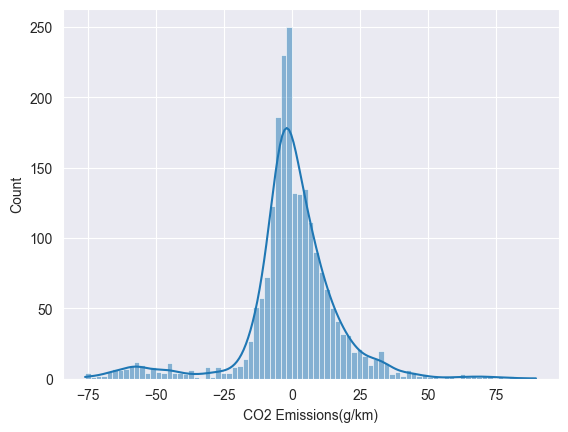

In [32]:
#residuals:
residuals = y_test - predictions
sns.histplot(residuals, kde = True)

Text(0, 0.5, 'predicted values')

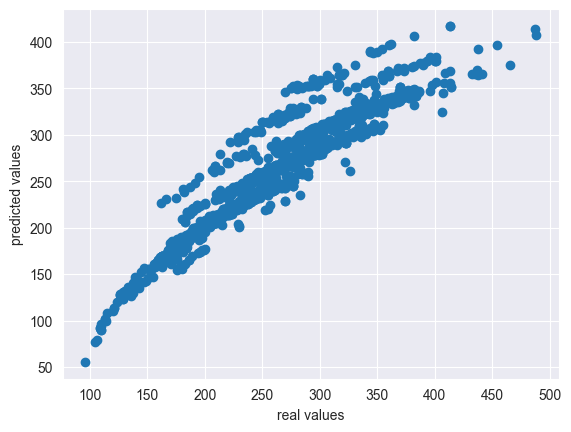

In [35]:
#scatter plot of real values vs predicted values:
plt.scatter(x = y_test, y = predictions)
plt.xlabel('real values')
plt.ylabel('predicted values')

In [36]:
#bias variance tradeoff
#skip it for now

In [40]:
#conclusion? what should be increased or decreased?
pd.DataFrame(data = model.coef_, index = x.columns, columns = ['Coefficients'])

,Coefficients
Engine Size(L),4.642407
Cylinders,7.572045
Fuel Consumption City (L/100 km),1.298978
Fuel Consumption Hwy (L/100 km),4.958553
Fuel Consumption Comb (L/100 km),0.011202
Fuel Consumption Comb (mpg),-3.368786


# **Conclusion**

In [ ]:
#increase = fuel efficiency (mpg)
#decrease = engine size, number of cylinders